In [1]:
import sys, os

# project root = one folder above /notebooks/
project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.append(project_root)

print("CLuster_KMEans:", project_root)


CLuster_KMEans: d:\Download\ecoml


In [2]:
import importlib

import ecoml.tracker
import ecoml.ui

importlib.reload(ecoml.tracker)
importlib.reload(ecoml.ui)

print("EcoML modules reloaded.")


EcoML modules reloaded.


In [3]:
from ecoml.tracker import EcoTracker
from ecoml.ui import CellHook

tracker = EcoTracker(log_path="../data/emissions_log.csv")
hook = CellHook(tracker)
hook.register()

EcoML tracking enabled — with live insights!


In [4]:
import torch

if torch.cuda.is_available():
    print(f"✅ Success! PyTorch is using GPU: {torch.cuda.get_device_name(0)}")
else:
    print("⛔️ Error: PyTorch is still using CPU.")
    print("If you see this, try restarting your VS Code or Jupyter kernel and run this cell again.")

✅ Success! PyTorch is using GPU: NVIDIA GeForce MX330


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score






In [6]:
data = pd.read_csv('environmental factors.csv')

In [7]:
data.head()

,temperature,humidity,wind_speed,carbon_emissions,solar_irradiance,pollution_level
0,22.490802,52.418449,19.599966,337.165056,369.020837,84.723658
1,34.014286,49.974726,8.690240,256.681604,185.335998,49.451704
2,29.639879,40.569235,11.932794,484.024336,213.723302,19.546561
3,26.973170,66.436000,18.265613,148.540303,262.604015,73.664179
4,18.120373,58.597450,14.641787,314.535387,283.288001,41.867814


In [8]:
data.tail()

,temperature,humidity,wind_speed,carbon_emissions,solar_irradiance,pollution_level
9995,32.153120,82.622318,24.045509,389.315259,660.200681,96.614073
9996,32.950177,32.808837,19.956484,394.037121,303.574216,37.323996
9997,33.934158,48.221908,5.389117,171.306244,774.095576,30.467486
9998,22.949760,56.599200,13.020097,245.443897,568.909821,40.736253
9999,19.342808,40.335889,10.147960,269.340664,875.536039,52.283339


In [9]:
scalar = StandardScaler()
data_scaled = scalar.fit_transform(data)

print(pd.DataFrame(data_scaled, columns=data.columns).head())

   temperature  humidity  wind_speed  carbon_emissions  solar_irradiance  \
0    -0.415900 -0.452465    0.801884          0.482494         -0.684316   
1     1.587377 -0.593258   -1.100359         -0.136414         -1.389866   
2     0.826917 -1.135149   -0.534981          1.611824         -1.280827   
3     0.363328  0.355146    0.569224         -0.968007         -1.093072   
4    -1.175669 -0.096466   -0.062635          0.308475         -1.013623   

   pollution_level  
0         1.193409  
1        -0.029923  
2        -1.067119  
3         0.809835  
4        -0.292954  


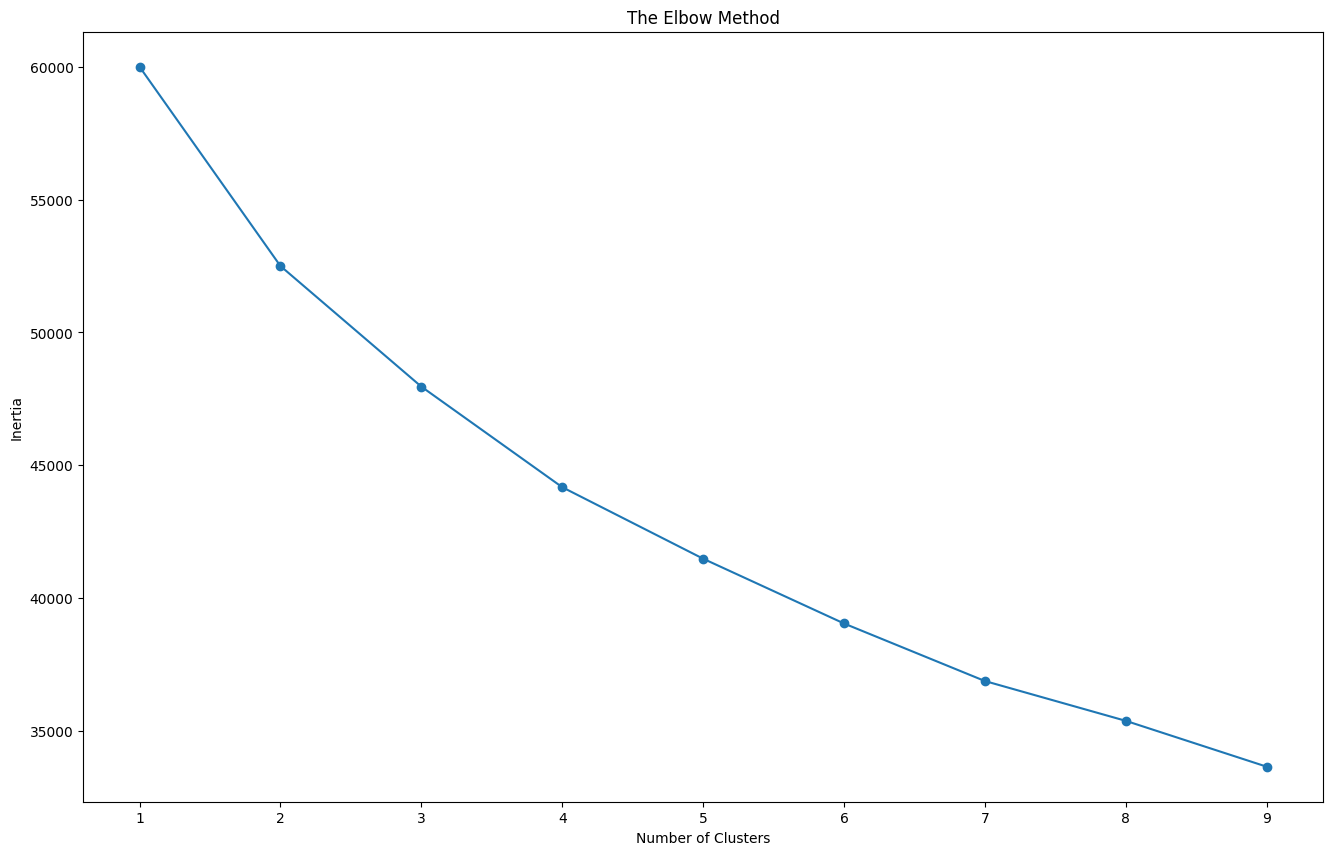

In [10]:
#use  the elbow method
intertia=[]
k_range = range(1,10)
for k in k_range:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(data_scaled)
    intertia.append(kmeans.inertia_)

plt.figure(figsize=(16,10))
plt.plot(k_range,intertia,marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('The Elbow Method')
plt.show()

In [11]:
k =2
kmeans = KMeans(n_clusters=k,random_state =42)
data['cluster']=kmeans.fit_predict(data_scaled)
print(data.head())

   temperature   humidity  wind_speed  carbon_emissions  solar_irradiance  \
0    22.490802  52.418449   19.599966        337.165056        369.020837   
1    34.014286  49.974726    8.690240        256.681604        185.335998   
2    29.639879  40.569235   11.932794        484.024336        213.723302   
3    26.973170  66.436000   18.265613        148.540303        262.604015   
4    18.120373  58.597450   14.641787        314.535387        283.288001   

   pollution_level  cluster  
0        84.723658        1  
1        49.451704        0  
2        19.546561        0  
3        73.664179        1  
4        41.867814        0  


In [12]:
sil_score = silhouette_score(data_scaled,data['cluster'])
print('Silhouette Score:',sil_score)

Silhouette Score: 0.12329174489534976


<Axes: xlabel='carbon_emissions', ylabel='pollution_level'>

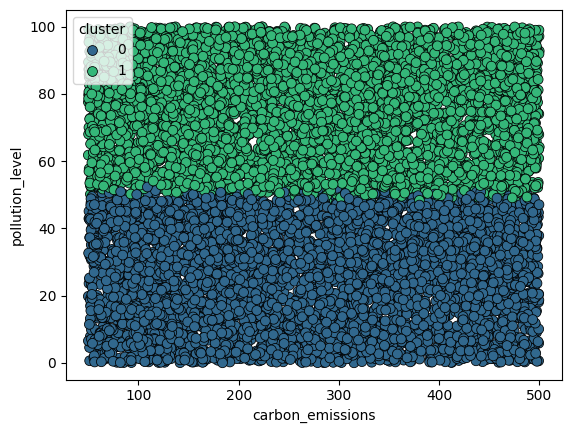

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(x=data['carbon_emissions'],y=data['pollution_level'],hue=data['cluster'],palette='viridis',edgecolor='k',s=50)

In [14]:
!ls -R /content


'ls' is not recognized as an internal or external command,
operable program or batch file.


In [15]:
df = pd.read_csv('Iris.csv')
df


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [16]:
df.drop(columns = 'Species')

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,1,5.1,3.5,1.4,0.2
1,2,4.9,3.0,1.4,0.2
2,3,4.7,3.2,1.3,0.2
3,4,4.6,3.1,1.5,0.2
4,5,5.0,3.6,1.4,0.2
...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3
146,147,6.3,2.5,5.0,1.9
147,148,6.5,3.0,5.2,2.0
148,149,6.2,3.4,5.4,2.3


In [17]:
scalar = StandardScaler()
df_numeric = df.drop(columns=['Id', 'Species'])
df_scaled = scalar.fit_transform(df_numeric)

print(pd.DataFrame(df_scaled, columns=df_numeric.columns).head())

   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0      -0.900681      1.032057      -1.341272     -1.312977
1      -1.143017     -0.124958      -1.341272     -1.312977
2      -1.385353      0.337848      -1.398138     -1.312977
3      -1.506521      0.106445      -1.284407     -1.312977
4      -1.021849      1.263460      -1.341272     -1.312977


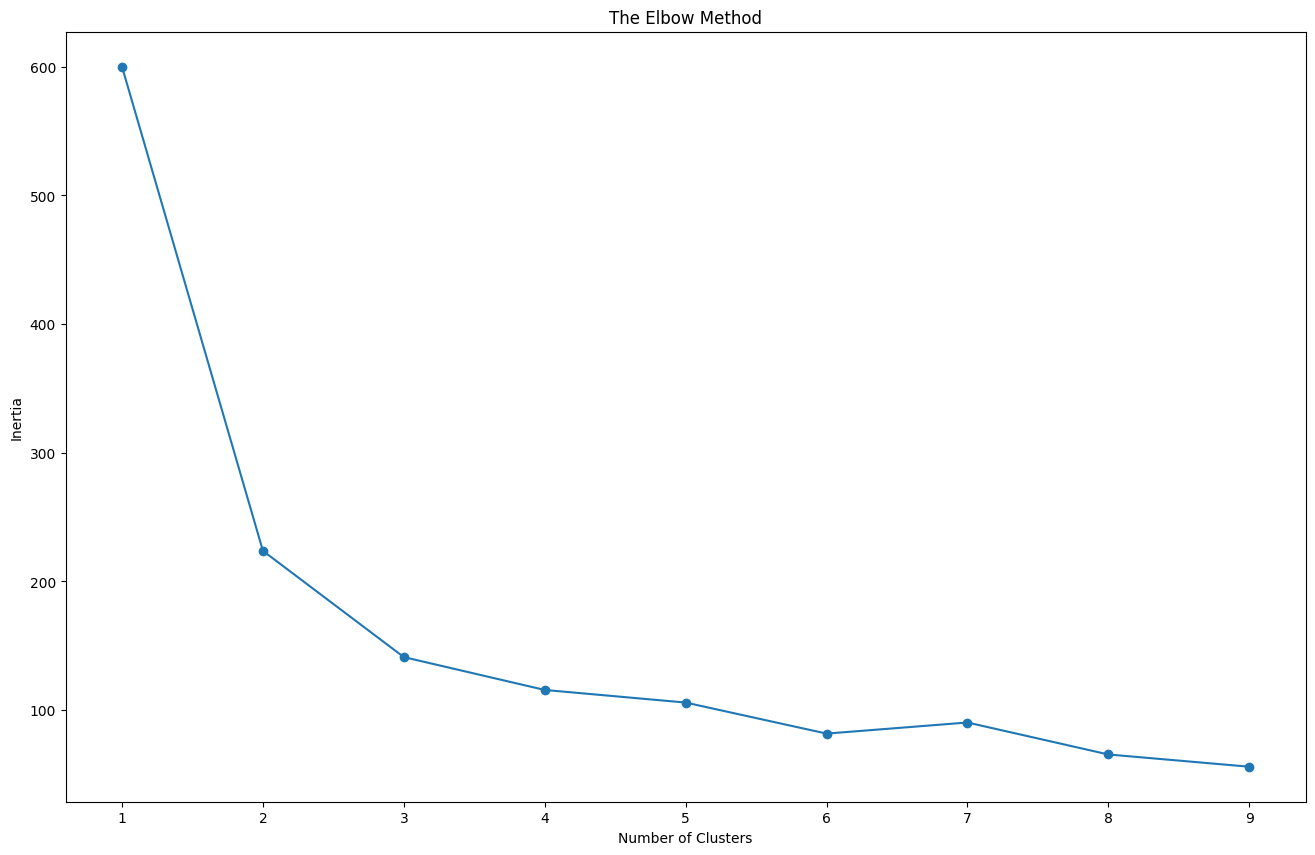

In [18]:
#use  the elbow method
intertia=[]
k_range = range(1,10)
for k in k_range:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(df_scaled)
    intertia.append(kmeans.inertia_)

plt.figure(figsize=(16,10))
plt.plot(k_range,intertia,marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('The Elbow Method')
plt.show()

In [19]:
k =2
kmeans = KMeans(n_clusters=k,random_state =42)
df['cluster']=kmeans.fit_predict(df_scaled)
print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species  \
0   1            5.1           3.5            1.4           0.2  Iris-setosa   
1   2            4.9           3.0            1.4           0.2  Iris-setosa   
2   3            4.7           3.2            1.3           0.2  Iris-setosa   
3   4            4.6           3.1            1.5           0.2  Iris-setosa   
4   5            5.0           3.6            1.4           0.2  Iris-setosa   

   cluster  
0        1  
1        1  
2        1  
3        1  
4        1  


In [20]:
sil_score = silhouette_score(df_scaled,df['cluster'])
print('Silhouette Score:',sil_score)

Silhouette Score: 0.580184463257396


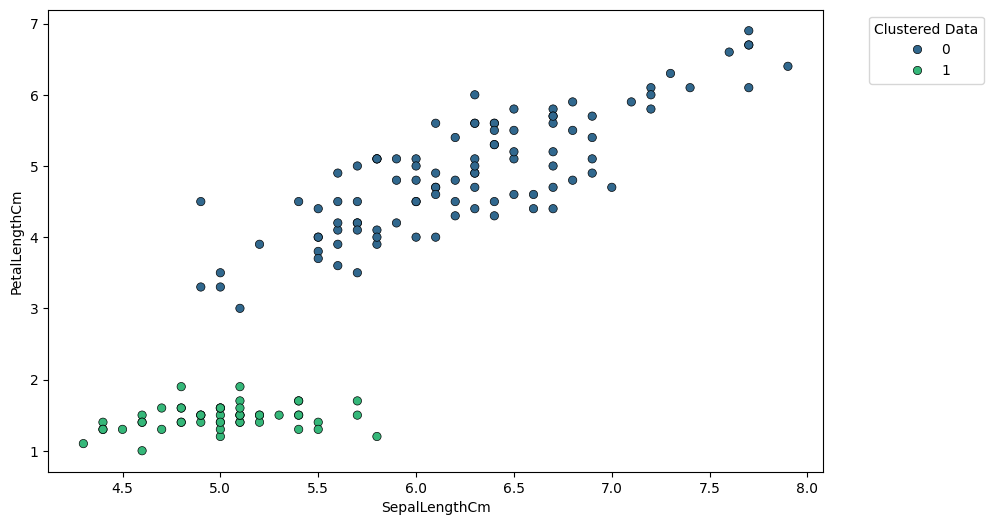

In [21]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='SepalLengthCm', y='PetalLengthCm', hue = 'cluster', data = df, palette = 'viridis',edgecolor='k')
plt.legend(title='Clustered Data', bbox_to_anchor = (1.05,1), loc='upper left')

In [22]:
import pandas as pd
import numpy as np

In [23]:
data = pd.read_csv('environmental_socioeconomic.csv')

In [24]:
data

,co2_emissions,waste_production,gdp,population
0,218.543053,436.276737,39199.932440,6.417631e+07
1,477.821438,399.620887,17380.479824,4.646995e+07
2,379.397274,258.538521,23865.587775,9.648535e+07
3,319.396318,646.540003,36531.225474,2.267887e+07
4,120.208388,528.961744,29283.573781,5.919779e+07
...,...,...,...,...
9995,435.945195,889.334766,48091.018014,7.564936e+07
9996,453.878976,142.132562,39912.968447,7.668817e+07
9997,476.018562,373.328622,10778.234513,2.768737e+07
9998,228.869597,498.988006,26040.193699,4.399766e+07


In [25]:
data.isnull().sum()

co2_emissions       0
waste_production    0
gdp                 0
population          0
dtype: int64

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns


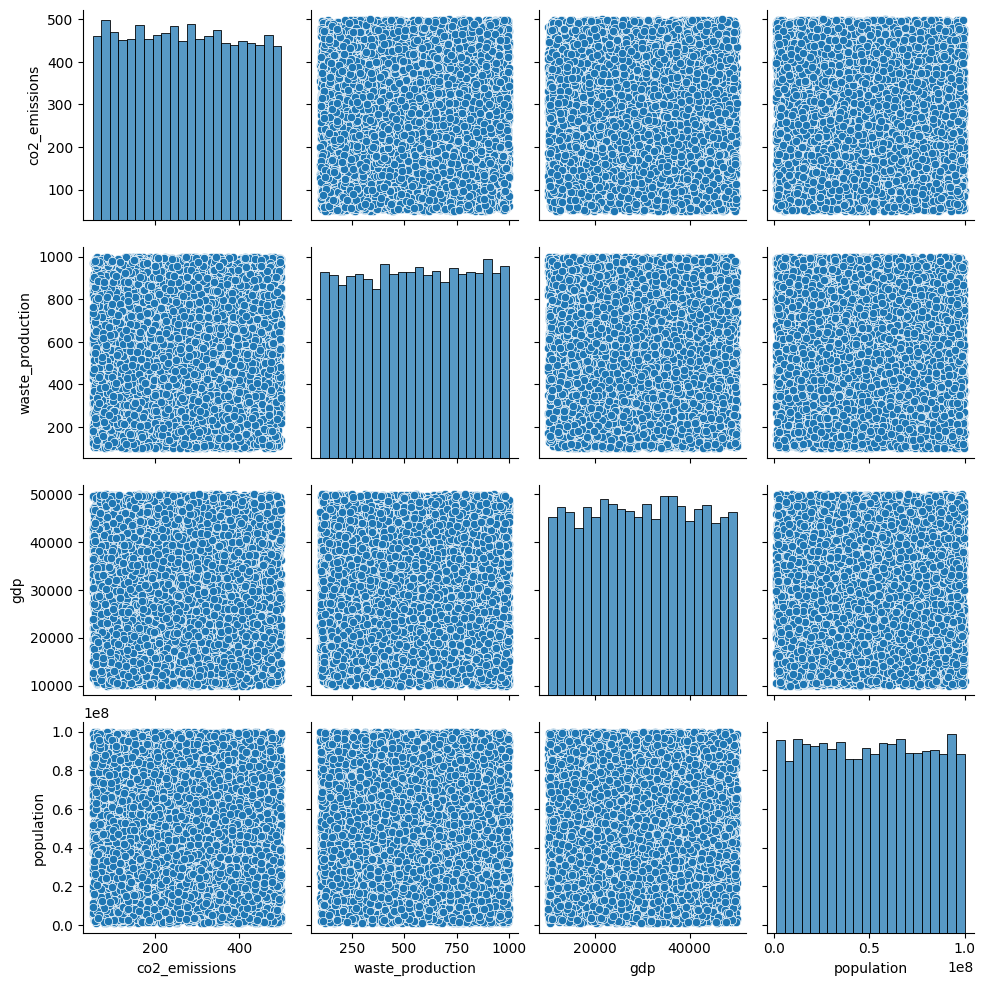

In [27]:
sns.pairplot(data)

In [28]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data_scaled= scaler.fit_transform(data)
print(pd.DataFrame(data_scaled , columns=data.columns).head())
data_scaled=pd.DataFrame(data_scaled , columns=data.columns)

   co2_emissions  waste_production       gdp  population
0      -0.415900         -0.452465  0.801884    0.482494
1       1.587377         -0.593258 -1.100359   -0.136414
2       0.826917         -1.135149 -0.534981    1.611824
3       0.363328          0.355146  0.569224   -0.968007
4      -1.175669         -0.096466 -0.062635    0.308475


In [29]:
data_scaled

,co2_emissions,waste_production,gdp,population
0,-0.415900,-0.452465,0.801884,0.482494
1,1.587377,-0.593258,-1.100359,-0.136414
2,0.826917,-1.135149,-0.534981,1.611824
3,0.363328,0.355146,0.569224,-0.968007
4,-1.175669,-0.096466,-0.062635,0.308475
...,...,...,...,...
9995,1.263827,1.287710,1.577019,0.883523
9996,1.402389,-1.582259,0.864048,0.919833
9997,1.573448,-0.694246,-1.675950,-0.792940
9998,-0.336114,-0.211594,-0.345396,-0.222831


<Axes: ylabel='population'>

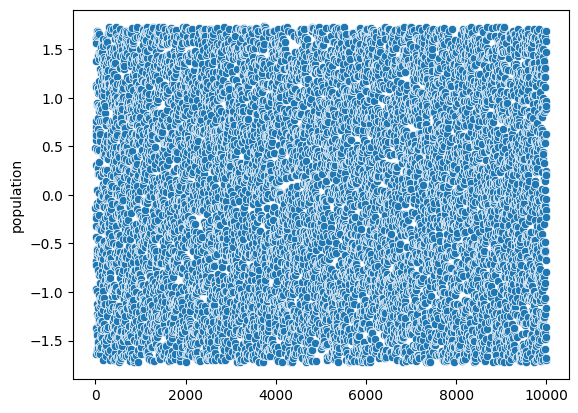

In [30]:
sns.scatterplot(data_scaled['population'])

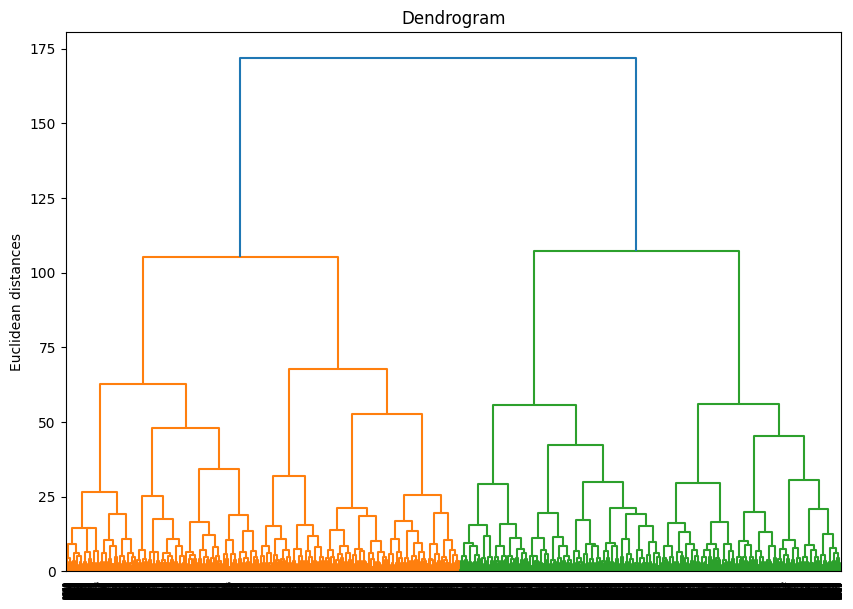

In [38]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
plt.figure(figsize=(10, 7))
dendrogram = sch.dendrogram(sch.linkage(data_scaled, method='ward'))
plt.title('Dendrogram')
plt.ylabel('Euclidean distances')
plt.show()

In [32]:
hierarchical = AgglomerativeClustering(n_clusters=4, linkage='ward')
data_scaled['cluster']=hierarchical.fit_predict(data_scaled)

In [33]:
print(data_scaled.head())

   co2_emissions  waste_production       gdp  population  cluster
0      -0.415900         -0.452465  0.801884    0.482494        3
1       1.587377         -0.593258 -1.100359   -0.136414        2
2       0.826917         -1.135149 -0.534981    1.611824        2
3       0.363328          0.355146  0.569224   -0.968007        1
4      -1.175669         -0.096466 -0.062635    0.308475        1


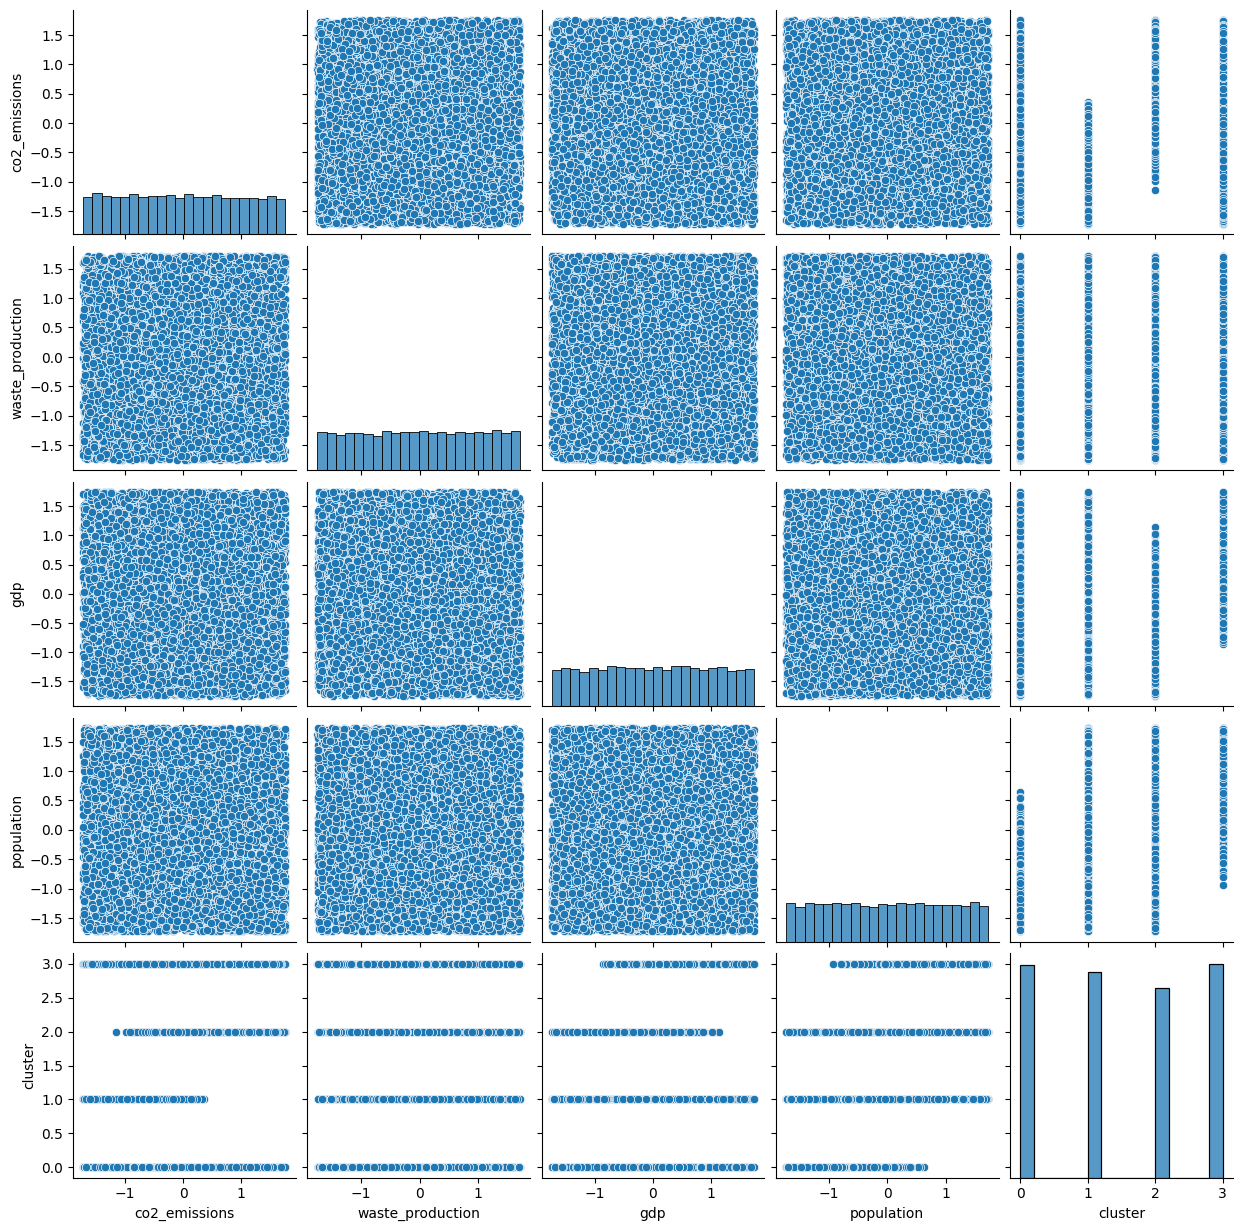

In [34]:
sns.pairplot(data_scaled)

<Axes: xlabel='cluster', ylabel='population'>

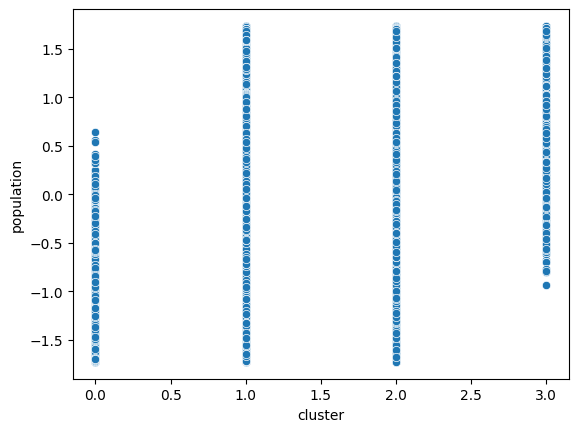

In [35]:
sns.scatterplot(x=data_scaled['cluster'], y=data_scaled['population'])

In [36]:
#Score
from sklearn.metrics import silhouette_score
score = silhouette_score(data_scaled, data_scaled['cluster'])
print(score)

0.25210044355513483


In [39]:
import torch
import time

print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Increase this number for more load (1 = ~1GB, depending on type)
GB_to_allocate = 6   # change to match your GPU capacity

print(f"\nAllocating ~{GB_to_allocate} GB on GPU...\n")

tensors = []
try:
    for i in range(GB_to_allocate):
        print(f"Allocating {i+1} GB...")
        t = torch.randn((1024, 1024, 256), device=device)  # ~1GB float32
        tensors.append(t)
        time.sleep(0.5)
except Exception as e:
    print("Stopped allocating due to error or GPU full:")
    print(e)

print("\nMemory allocated. Monitoring GPU usage...")
input("Press ENTER to release GPU memory...")

# Free GPU memory
del tensors
torch.cuda.empty_cache()

print("GPU memory cleared!")


CUDA available: True

Allocating ~6 GB on GPU...

Allocating 1 GB...
Allocating 2 GB...
Allocating 3 GB...
Allocating 4 GB...
Allocating 5 GB...
Allocating 6 GB...

Memory allocated. Monitoring GPU usage...
GPU memory cleared!
